# Desafio 4: Modelo Sec2Sec para traduccion de texto
## Alumno: Maxim Dorogov

### Consigna
- Implementar un modelo sec2sec para traducción de texto utilizando la librería PyTorch.

- Para los embeddings usar capas pre entrenadas como GloVe o FastText.

In [1]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

from matplotlib import pyplot as plt

from tqdm import tqdm
from typing import Dict

2025-10-12 21:26:31.799399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760315191.810956   66300 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760315191.814637   66300 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-12 21:26:31.828012: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Leemos y parseamos el archivo con pares de oraciones en ingles y español.

In [2]:
DATA_FILE = './spa-eng/spa.txt'
N_ROWS = 25000
# read only N first lines for faster testing
data = pd.read_csv(
    DATA_FILE, sep='\t', header=None, names=['eng', 'spa', 'other'], nrows=N_ROWS)
data = data[['eng', 'spa']]
print(f'Dataset size: {len(data)} pairs of sentences')
data.tail()


Dataset size: 25000 pairs of sentences


,eng,spa
24995,He failed after all.,Él fracasó a pesar de todo.
24996,He feels very happy.,Él se siente muy feliz.
24997,He felt very lonely.,Él se sentía muy solo.
24998,He felt very lonely.,Se sentía muy solo.
24999,He flew into a rage.,Él montó en cólera.


EL input sera la oracion en espanol y el output la oracion en ingles. Agregamos tokens de inicio y fin de secuencia.

In [3]:
data['input_raw'] = data['spa']
data['decoder_output'] = data['eng'] + ' <eos>'
data['decoder_input'] = '<sos> ' + data['eng']
data.head()

,eng,spa,input_raw,decoder_output,decoder_input
0,Go.,Ve.,Ve.,Go. <eos>,<sos> Go.
1,Go.,Vete.,Vete.,Go. <eos>,<sos> Go.
2,Go.,Vaya.,Vaya.,Go. <eos>,<sos> Go.
3,Go.,Váyase.,Váyase.,Go. <eos>,<sos> Go.
4,Hi.,Hola.,Hola.,Hi. <eos>,<sos> Hi.


### Preprocesamiento de datos

Tokenizamos y preparamos las secuencias de entrada y salida.

In [4]:
MAX_VOCAB_SIZE = 8000

### Input Tokenizer

input_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE, 
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')

input_tokenizer.fit_on_texts(data['input_raw'])
input_seq = input_tokenizer.texts_to_sequences(data['input_raw'])

word2idx_inputs = input_tokenizer.word_index
max_input_len = max(len(sen) for sen in input_seq)
print("Palabras en el vocabulario de entrada:", len(word2idx_inputs))
print("Sentencia de entrada más larga:", max_input_len)

### Output Tokenizer

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE, 
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')

output_tokenizer.fit_on_texts(data['decoder_output'].tolist() + ["<sos>", "<eos>"])
decoder_output_seq = output_tokenizer.texts_to_sequences(data['decoder_output'])
decoder_input_seq = output_tokenizer.texts_to_sequences(data['decoder_input'])


num_words_output = min(MAX_VOCAB_SIZE, len(output_tokenizer.word_index) + 1)

word2idx_outputs = output_tokenizer.word_index
max_output_len = max(len(sen) for sen in decoder_input_seq)
print("Palabras en el vocabulario de salida:", len(word2idx_outputs))
print("Sentencia de salida más larga:", max_output_len)

Palabras en el vocabulario de entrada: 8912
Sentencia de entrada más larga: 11
Palabras en el vocabulario de salida: 4335
Sentencia de salida más larga: 7


Calculamos el coverage del vocabulario para ver si el tamaño elegido es adecuado.
Iteramos sobre el valor de MAX_VOCAB_SIZE hasta ajustarlo al coverage deseado.
La idea es cubrir al menos el 95% del vocabulario con las palabras mas frecuentes.

In [5]:
# check actual coverage
sorted_items = sorted(
    input_tokenizer.word_counts.items(), key=lambda kv: kv[1], reverse=True)
total = sum(input_tokenizer.word_counts.values())
covered = sum(
    [count for _, count in sorted_items[:MAX_VOCAB_SIZE]])
coverage = covered / total
print(f"Vocab coverage: {coverage:.2%}")

Vocab coverage: 98.87%


Agregamos padding a las secuencias para que todas tengan la misma longitud.
>NOTA: Tener en cuenta que en el encoder los ceros se agregan al comienzo y en el decoder al final. Esto es porque la salida del encoder está basada en las últimas palabras de la sentencia (son las más importantes), mientras que en el decoder está basada en el comienzo de la secuencia de salida ya que es la realimentación del sistema y termina con fin de sentencia.

In [6]:
max_input_len = 16
max_out_len = 16

encoder_input_sequences = pad_sequences(input_seq, maxlen=max_input_len)

decoder_input_sequences = pad_sequences(
    decoder_input_seq, maxlen=max_out_len, padding='post')

decoder_output_sequences = pad_sequences(
    decoder_output_seq, maxlen=max_out_len, padding='post')
decoder_targets = decoder_output_sequences
# Nota: decoder_output_sequences tiene que ser one-hot encoded
# decoder_targets = F.one_hot(
#     torch.tensor(decoder_output_sequences, dtype=torch.long), num_classes=num_words_output).numpy()


### Embeddings pre entrenados

In [7]:
class GloveEmbeddings:

    def __init__(self, path=None, word_max_size=60):

        self.embeddings = self._load_glove_embeddings(path)
        # build the vocabulary hashmap
        index = np.arange(len(self.embeddings))
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings.keys(), index))
        self.idx2word = dict(zip(index, self.embeddings.keys()))
        self._n_features = len(list(self.embeddings.values())[1])

    @staticmethod
    def _load_glove_embeddings(filepath: str) -> Dict[str, np.ndarray]:
        """
        Loads GloVe word embeddings from a file and stores them in a dictionary.

        Args:
            filepath (str): The path to the GloVe .vec file.

        Returns:
            dict: A dictionary mapping words to their corresponding numpy vector arrays.
        """
        embeddings_dict = {}
        
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                
                # Split the line into word and vector values
                values = line.split()

                word = values[0]
                if word.isnumeric():  # skip numeric-only "words"
                    continue
                # if some malformed line, skip it
                try:
                    vector = np.asarray(values[1:], dtype='float32')
                except ValueError:
                    continue
                embeddings_dict[word] = vector

        print(f"Loaded {len(embeddings_dict)} word vectors.")
        return embeddings_dict

    def get_words_embeddings(self, words):
        return np.array([
            self.embeddings.get(word, np.zeros(self._n_features)) for word in words])

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

Usamos GloVe en español e inglés. Los ebeddings en español son de 300 dimensiones y los de inglés de 50 dimensiones.

>NOTA: Los archivos de embeddings son pesados, por lo que no los subo al repositorio. Se pueden descargar de los siguientes links:
- Inglés: https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.50d.zip
- Español: https://github.com/dccuchile/spanish-word-embeddings#glove-embeddings-from-sbwc

In [8]:
spanish_emb = GloveEmbeddings("./glove-sbwc.i25.vec")
english_emb = GloveEmbeddings("./glove.2024.wikigiga.50d/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt")

Loaded 855339 word vectors.
Loaded 1277237 word vectors.


Armo las matrices de embeddings para el encoder y decoder usando los embeddings pre entrenados.

In [9]:
def create_embedding_matrix(
    glove_embeddings, word2index, max_vocab_size):
    """
    Create an embedding matrix for the given tokenizer using pre-trained GloVe embeddings.
    """
    embedding_matrix = np.zeros((max_vocab_size, glove_embeddings._n_features))
    for word, i in word2index.items():
        if i >= max_vocab_size:
            continue
        embedding_vector = glove_embeddings.get_words_embeddings([word])[0]
        embedding_matrix[i] = embedding_vector
    return embedding_matrix

In [10]:
spanish_emb_matrix = create_embedding_matrix(
    spanish_emb, word2idx_inputs, MAX_VOCAB_SIZE)

english_emb_matrix = create_embedding_matrix(
    english_emb, word2idx_outputs, MAX_VOCAB_SIZE)

print("Spanish embedding matrix shape:", spanish_emb_matrix.shape)
print("English embedding matrix shape:", english_emb_matrix.shape)

Spanish embedding matrix shape: (8000, 300)
English embedding matrix shape: (8000, 50)


### Arquitectura del modelo

In [11]:
class Encoder(nn.Module):
    def __init__(
        self, vocab_size, embedding_matrix, lstm_layers=1, lstm_hidden_size=64):
        super().__init__()

        self.embedding_dim = embedding_matrix.shape[1]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=self.embedding_dim, 
            padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False # freeze embedding layer

        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=lstm_hidden_size, 
            batch_first=True,
            num_layers=lstm_layers)

    def forward(self, x):
        out = self.embedding(x)
        _, (ht, ct) = self.lstm(out)
        return (ht, ct)

class Decoder(nn.Module):
    def __init__(
        self, vocab_size, embedding_matrix, lstm_layers=1, lstm_hidden_size=64):
        super().__init__()

        self.embedding_dim = embedding_matrix.shape[1]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=self.embedding_dim, 
            padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False # freeze embedding layer

        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=lstm_hidden_size, 
            batch_first=True,
            num_layers=lstm_layers)
        self.fc = nn.Linear(lstm_hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        # out = F.log_softmax(out, dim=-1)
        return out, hidden

class Seq2Seq(nn.Module):
    def __init__(
        self, 
        encoder: Encoder, 
        decoder: Decoder
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg):
        batch_size, trg_len = trg.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size)

        hidden = self.encoder(src)

        input = trg[:, 0].unsqueeze(1)  # first input to the decoder is the <sos> token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output.squeeze(1)
            top1 = output.argmax(2)
            input = top1  # teacher forcing
        return outputs

In [12]:
encoder = Encoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=spanish_emb_matrix,
    lstm_layers=2,
    lstm_hidden_size=64)
decoder = Decoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=english_emb_matrix,
    lstm_layers=2,
    lstm_hidden_size=64)
seq2seq = Seq2Seq(encoder, decoder)

summary(seq2seq, input_data=[
    torch.randint(0, MAX_VOCAB_SIZE, (1, max_input_len)),
    torch.randint(0, MAX_VOCAB_SIZE, (1, max_out_len))
])

Layer (type:depth-idx)                   Output Shape              Param #
Seq2Seq                                  [1, 16, 8000]             --
├─Encoder: 1-1                           [2, 1, 64]                --
│    └─Embedding: 2-1                    [1, 16, 300]              (2,400,000)
│    └─LSTM: 2-2                         [1, 16, 64]               126,976
├─Decoder: 1-2                           [1, 1, 8000]              --
│    └─Embedding: 2-3                    [1, 1, 50]                (400,000)
│    └─LSTM: 2-4                         [1, 1, 64]                62,976
│    └─Linear: 2-5                       [1, 1, 8000]              520,000
├─Decoder: 1-3                           [1, 1, 8000]              (recursive)
│    └─Embedding: 2-6                    [1, 1, 50]                (recursive)
│    └─LSTM: 2-7                         [1, 1, 64]                (recursive)
│    └─Linear: 2-8                       [1, 1, 8000]              (recursive)
├─Decoder: 1-4     

### Entrenamiento

In [13]:
class SequenceDataset(Dataset):
    def __init__(self, encoder_input, decoder_input, decoder_output):
        # Convertir los arrays de numpy a tensores. 
        # pytorch espera en general entradas 32bits
        self.encoder_inputs = torch.from_numpy(encoder_input.astype(np.int32))
        self.decoder_inputs = torch.from_numpy(decoder_input.astype(np.int32))
        # Transformar los datos a oneHotEncoding
        # la loss function esperan la salida float
        self.decoder_outputs = decoder_output
        self.len = self.decoder_outputs.shape[0]

    def __getitem__(self,index):
        return self.encoder_inputs[index], self.decoder_inputs[index], self.decoder_outputs[index]

    def __len__(self):
        return self.len

In [14]:
dataset = SequenceDataset(
    encoder_input_sequences, decoder_input_sequences, decoder_output_sequences)

BATCH_SIZE = 128
VAL_SPLIT = 0.2

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [1 - VAL_SPLIT, VAL_SPLIT])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Tamaño del dataset de entrenamiento: {len(train_dataset)}')
print(f'Tamaño del dataset de validación: {len(val_dataset)}')


Tamaño del dataset de entrenamiento: 20000
Tamaño del dataset de validación: 5000


In [15]:
def sequence_acc(y_pred, y_test):
    y_pred_tag = y_pred.data.max(dim=-1,keepdim=True)[1]
    y_test_tag = y_test.data.max(dim=-1,keepdim=True)[1]

    batch_size = y_pred_tag.shape[0]
    batch_acc = torch.zeros(batch_size)
    for b in range(batch_size):
        correct_results_sum = (y_pred_tag[b] == y_test_tag[b]).sum().float()
        batch_acc[b] = correct_results_sum / y_pred_tag[b].shape[0]

    correct_results_sum = batch_acc.sum().float()
    acc = correct_results_sum / batch_size
    return acc

def perplexity(loss_value: float) -> float:
    try:
        perplexity = np.exp(loss_value)
    except OverflowError:
        perplexity = float('inf')
    return perplexity

def evaluate(model, data_loader, loss_fn) -> tuple[float, float]:
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for encoder_input, decoder_input, target in \
            tqdm(data_loader, desc="Validation"):
            encoder_input = encoder_input.to('cuda')
            decoder_input = decoder_input.to('cuda')
            target = target.to('cuda')
            
            logits = model(encoder_input, decoder_input)
            logits = logits.reshape(-1, logits.size(-1))
            targets = target.reshape(-1).long()
            loss = loss_fn(logits.to('cuda'), targets.to('cuda'))
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    ppl = perplexity(avg_loss)
    return avg_loss, ppl

Validation: 100%|██████████| 40/40 [00:01<00:00, 32.87it/s]


Val loss improved from inf to 1.7379435092210769, saving model at epoch 1
Epoch 1/100, Loss: 3.1486, Val Loss: 1.7379


Validation: 100%|██████████| 40/40 [00:01<00:00, 32.64it/s]


Val loss improved from 1.7379435092210769 to 1.6547591596841813, saving model at epoch 2
Epoch 2/100, Loss: 1.6845, Val Loss: 1.6548


Validation: 100%|██████████| 40/40 [00:01<00:00, 32.54it/s]


...

Epoch 50/100, Loss: 0.9099, Val Loss: 1.2490


Validation: 100%|██████████| 40/40 [00:01<00:00, 35.87it/s]


Epoch 51/100, Loss: 0.9025, Val Loss: 1.2519


Validation: 100%|██████████| 40/40 [00:01<00:00, 35.00it/s]

Early stopping at epoch 52


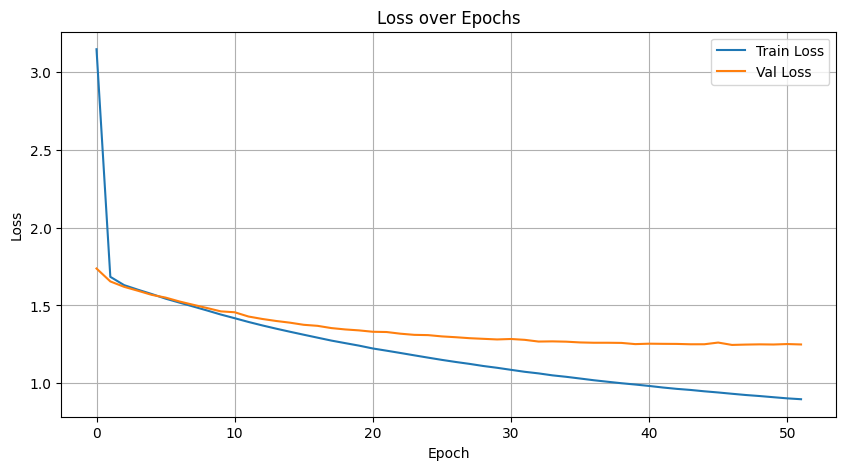

In [16]:
encoder = Encoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=spanish_emb_matrix,
    lstm_layers=2,
    lstm_hidden_size=64)
decoder = Decoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=english_emb_matrix,
    lstm_layers=2,
    lstm_hidden_size=64)
model = Seq2Seq(encoder, decoder).to('cuda')

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

EPOCHS = 100

train_loss_avg = list()
eval_loss_avg = list()

max_patience = 5
patience = 0
best_val_loss = float('inf')

for epoch in range(EPOCHS):

    model.train()
    epoch_loss = 0

    for encoder_input, decoder_input, target \
        in tqdm(train_dataloader, desc=f"Training: Epoch {epoch+1}/{EPOCHS}"):    
        encoder_input = encoder_input.to('cuda')
        decoder_input = decoder_input.to('cuda')
        target = target.to('cuda')

        optimizer.zero_grad()
        output = model(encoder_input, decoder_input)

        # reshape
        logits = output.reshape(-1, output.size(-1))
        targets = target.reshape(-1).long()

        loss = criterion(logits.cuda(), targets.cuda())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss_avg.append(epoch_loss / len(train_dataloader))
    eval_loss, _ = evaluate(model, val_dataloader, criterion)
    eval_loss_avg.append(eval_loss)

    # save model if metric improves:
    if epoch == 0 or eval_loss < best_val_loss:
        patience = 0
        print(
            f'Val loss improved from {best_val_loss if epoch > 0 else "inf"} to {eval_loss}, '
            f'saving model at epoch {epoch+1}')
        torch.save(
            model.state_dict(),
            f"./{model.__class__.__name__}_best.pth")
        best_val_loss = eval_loss
    else:
        patience += 1
        if patience >= max_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(
        f"Epoch {epoch+1}/{EPOCHS}, Loss: {train_loss_avg[-1]:.4f}, "
        f"Val Loss: {eval_loss_avg[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_loss_avg)
plt.plot(eval_loss_avg)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend(['Train Loss', 'Val Loss'])
plt.show()


In [20]:
# save word2idx mappings
import json
with open('word2idx_inputs.json', 'w') as f:
    json.dump(word2idx_inputs, f)
with open('word2idx_outputs.json', 'w') as f:
    json.dump(word2idx_outputs, f)

encoder = Encoder(
    vocab_size=MAX_VOCAB_SIZE,
    lstm_layers=2,
    embedding_matrix=spanish_emb_matrix,
)
decoder = Decoder(
    vocab_size=MAX_VOCAB_SIZE,
    lstm_layers=2,
    embedding_matrix=english_emb_matrix,
)
_model = Seq2Seq(
    encoder=encoder,
    decoder=decoder
).to('cuda')
_model.load_state_dict(torch.load(
    './Seq2Seq_best.pth', map_location='cuda'))

<All keys matched successfully>